# Homes Dataset - EDA and Linear Regression

## 1) Download the data file above and read it into a pandas DataFrame.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option('display.max_columns', None)

path = r"C:\Users\yshah\Documents\OIM7502_F25\data\homes.csv"

df = pd.read_csv(path)




## 2) Describe the dataset (code)


In [13]:
# Information about rows, columns, and data types
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)

# Summary statistics for all numeric variables
print("\nDescriptive Statistics:\n")
display(df.describe())

# Check for missing values in each column
print("\nMissing Values:\n")
print(df.isna().sum())



Shape of dataset: (51, 9)

Data types:
 Sell       object
List      float64
Living    float64
Rooms     float64
Beds      float64
Baths     float64
Age       float64
Acres     float64
Taxes     float64
dtype: object

Descriptive Statistics:



,List,Living,Rooms,Beds,Baths,Age,Acres,Taxes
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,178.340000,21.120000,8.060000,3.820000,1.860000,30.220000,1.020600,3706.100000
std,79.382723,8.351072,1.284285,0.690755,0.756199,30.962314,1.191496,1579.915268
min,90.000000,10.000000,5.000000,3.000000,1.000000,2.000000,0.220000,1445.000000
25%,140.000000,17.000000,7.000000,3.000000,1.000000,12.250000,0.382500,3107.000000
50%,160.000000,20.000000,8.000000,4.000000,2.000000,24.500000,0.550000,3490.000000
75%,190.000000,22.750000,9.000000,4.000000,2.000000,37.000000,1.182500,3919.250000
max,625.000000,64.000000,12.000000,6.000000,4.000000,202.000000,6.490000,12192.000000



Missing Values:

Sell      0
List      1
Living    1
Rooms     1
Beds      1
Baths     1
Age       1
Acres     1
Taxes     1
dtype: int64


## 3) Describe the dataset (markdown commentary)


## Dataset Description

What this dataset contains:  
The dataset provides information on homes and their sale characteristics, including sale price, list price, size, and property features.  
Each row represents one home sale.

Variables overview:
- `Sell`: Selling price of the home (in thousands of dollars).  
- `List`: Listing price of the home (in thousands of dollars).  
- `Living`: Living area in hundreds of square feet.  
- `Rooms`: Total number of rooms.  
- `Beds`: Number of bedrooms.  
- `Baths`: Number of bathrooms.  
- `Age`: Age of the house in years.  
- `Acres`: Lot size in acres.  
- `Taxes`: Annual property taxes (in U.S. dollars).  

Why this step matters:  
Describing the dataset helps us understand the autonomy of each variable before performing exploratory analysis. It also allows us to spot potential issues such as missing data, incorrect types, or unusual values.


## 4) EDA #1 — Univariate distributions

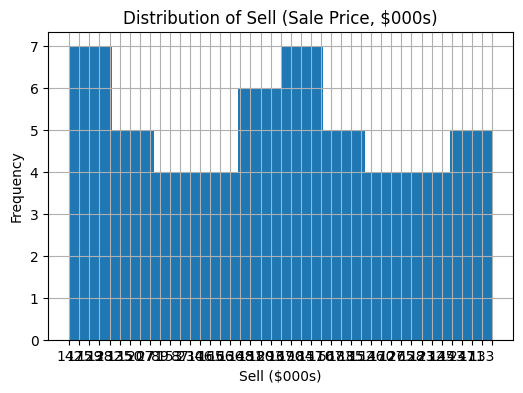

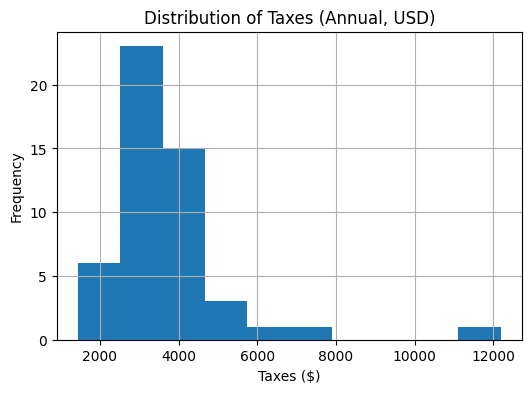

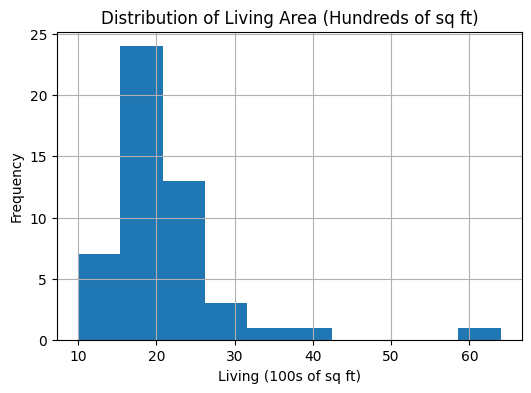

In [15]:
# Plot histograms for key variables

fig, ax = plt.subplots(figsize=(6,4))
df['Sell'].dropna().hist(ax=ax, bins=10)
ax.set_title('Distribution of Sell (Sale Price, $000s)')
ax.set_xlabel('Sell ($000s)')
ax.set_ylabel('Frequency')
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
df['Taxes'].dropna().hist(ax=ax, bins=10)
ax.set_title('Distribution of Taxes (Annual, USD)')
ax.set_xlabel('Taxes ($)')
ax.set_ylabel('Frequency')
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
df['Living'].dropna().hist(ax=ax, bins=10)
ax.set_title('Distribution of Living Area (Hundreds of sq ft)')
ax.set_xlabel('Living (100s of sq ft)')
ax.set_ylabel('Frequency')
plt.show()




## Univariate Analysis — Results and Interpretation

The histograms above show how each key numeric variable is distributed in the dataset:

- **Sell (Sale Price):**  
  The sale prices range widely from about $80K - $550K. The distribution appears uneven but roughly centered between $140K - $250K, with no clear symmetry. This suggests some clustering in common price ranges but also notable variability in housing values.

- **Taxes (Annual Property Taxes):**  
  The distribution is heavily right-skewed, meaning most homes pay between $2,000 - $5,000 in property taxes, but a few outliers pay above $10,000. These high-tax properties are likely the more expensive or larger homes.

- **Living (Living Area):**  
  Most homes fall between 10 and 25 hundred square feet (1,000–2,500 sq. ft.), while a small number extend beyond 50 hundred square feet (5,000 sq. ft.). This also shows a right-skew, suggesting that large homes are rare in the dataset.

**Summary:**  
Across all three variables, the data are positively skewed with a few large-value outliers. This pattern is typical for housing datasets, where a small number of high-value or large homes can disproportionately affect averages. These insights will help guide model selection and transformations in the next steps.



## 4) EDA #2 — Bivariate relationships

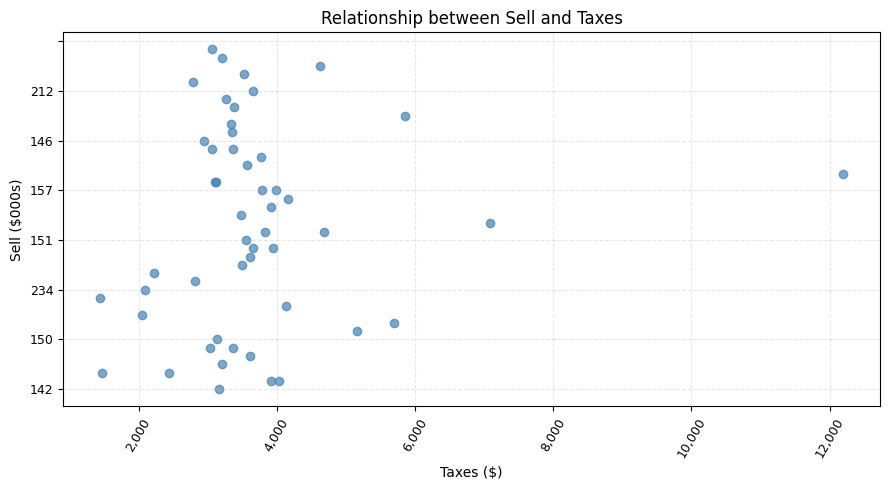

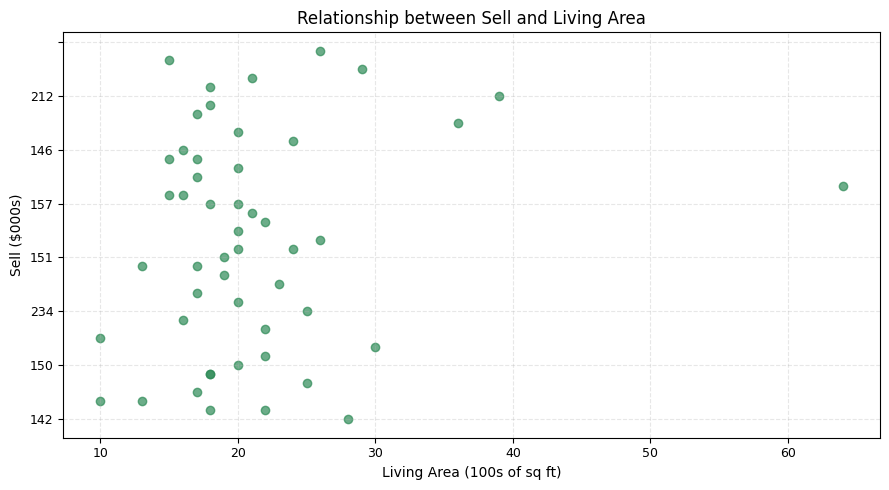

In [19]:
import matplotlib.ticker as mtick

# Relationship between Selling Price and Taxes
fig, ax = plt.subplots(figsize=(9,5)) 
ax.scatter(df['Taxes'], df['Sell'], color='steelblue', alpha=0.7)
ax.set_title('Relationship between Sell and Taxes', fontsize=12)
ax.set_xlabel('Taxes ($)', fontsize=10)
ax.set_ylabel('Sell ($000s)', fontsize=10)

# Format axis (to fix error of overlapping figures on y-axis (used ai for help on this part))
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')) 
ax.yaxis.set_major_locator(plt.MaxNLocator(8))                     
plt.xticks(rotation=60, fontsize=9)
plt.yticks(fontsize=9)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Relationship between Selling Price and Living Area
fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(df['Living'], df['Sell'], color='seagreen', alpha=0.7)
ax.set_title('Relationship between Sell and Living Area', fontsize=12)
ax.set_xlabel('Living Area (100s of sq ft)', fontsize=10)
ax.set_ylabel('Sell ($000s)', fontsize=10)

# Format axis
ax.yaxis.set_major_locator(plt.MaxNLocator(8))
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()




## Bivariate Analysis — Results and Interpretation

The scatterplots above show the relationships between the dependent variable `Sell` and two potential predictors: `Taxes` and `Living`.

**Sell vs Taxes:**  
The scatterplot shows a positive but somewhat weak relationship between property taxes and selling price. As property taxes increase, selling prices tend to increase as well, but the data points are spread out, indicating variability. This suggests that while higher taxes often accompany higher-valued homes, taxes alone are not a strong predictor of price — other factors likely play a role.

**Sell vs Living:**  
The relationship between living area and selling price is clearer and more linear. Homes with larger living areas generally sell for higher prices, and the upward trend is more consistent than in the taxes plot. There are a few larger homes (outliers), but they follow the same direction as the rest of the data.

**Summary:**  
Both variables are positively related to selling price. However, living area appears to be a stronger and more direct predictor of home value than property taxes. This observation aligns with real-world expectations; the size of a home typically has a more immediate influence on its market price than its tax burden.


## 4) EDA #3 — Correlations

In [24]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Display full correlation matrix
print("Correlation Matrix:")
display(corr_matrix)

# Show covariance matrix
print("\nCovariance Matrix:")
display(df.cov(numeric_only=True))




Correlation Matrix:


,List,Living,Rooms,Beds,Baths,Age,Acres,Taxes
List,1.000000,0.891618,0.570704,0.320470,0.640295,-0.130325,0.166838,0.906636
Living,0.891618,1.000000,0.750933,0.467277,0.668437,0.125075,0.177488,0.810243
Rooms,0.570704,0.750933,1.000000,0.656557,0.555187,0.371237,0.282448,0.516593
Beds,0.320470,0.467277,0.656557,1.000000,0.458682,0.141205,0.036832,0.313638
Baths,0.640295,0.668437,0.555187,0.458682,1.000000,-0.023063,0.301119,0.582622
Age,-0.130325,0.125075,0.371237,0.141205,-0.023063,1.000000,0.303733,-0.189221
Acres,0.166838,0.177488,0.282448,0.036832,0.301119,0.303733,1.000000,0.059647
Taxes,0.906636,0.810243,0.516593,0.313638,0.582622,-0.189221,0.059647,1.000000



Covariance Matrix:


,List,Living,Rooms,Beds,Baths,Age,Acres,Taxes
List,6301.616735,591.080816,58.183265,17.572653,38.436327,-320.321224,15.780200,1.137085e+05
Living,591.080816,69.740408,8.053878,2.695510,4.221224,32.340408,1.766049,1.069033e+04
Rooms,58.183265,8.053878,1.649388,0.582449,0.539184,14.762041,0.432208,1.048198e+03
Beds,17.572653,2.695510,0.582449,0.477143,0.239592,3.020000,0.030314,3.422837e+02
Baths,38.436327,4.221224,0.539184,0.239592,0.571837,-0.540000,0.271310,6.960755e+02
Age,-320.321224,32.340408,14.762041,3.020000,-0.540000,958.664898,11.205171,-9.256288e+03
Acres,15.780200,1.766049,0.432208,0.030314,0.271310,11.205171,1.419663,1.122834e+02
Taxes,113708.455102,10690.334694,1048.197959,342.283673,696.075510,-9256.287755,112.283408,2.496132e+06


## Correlation and Covariance Analysis — Summary

The correlation and covariance tables show how the numeric variables move together.

**What I did:**  
Calculated the correlation and covariance matrices to identify which variables are most related to `Sell` (selling price) and to spot strong interrelationships among predictors.

**Why:**  
This helps determine which factors are likely good predictors of price and whether any variables are too closely related, which could cause multicollinearity in regression.

**Key findings:**  
- `List`, `Living`, and `Taxes` are all strongly correlated with each other (around 0.8-0.9) and with `Sell`.  
- `Rooms`, `Beds`, and `Baths` show moderate positive relationships.  
- `Age` has weak or negative correlations, meaning older homes tend to sell for less.  
- `Acres` has little correlation with selling price.  
- Covariance values confirm the same direction of relationships but are in original units.

**Summary:**  
`List` and `Living` appear to be the best single predictors of selling price, while `Taxes` has a weaker but still positive association.


## 5) Linear Regression - Using Taxes as the independent variable and Sell as the dependent variable

In [3]:

import statsmodels.api as sm
import numpy as np
import pandas as pd

# Ensure numeric conversion and handle missing values
df['Sell'] = pd.to_numeric(df['Sell'], errors='coerce')
df['Taxes'] = pd.to_numeric(df['Taxes'], errors='coerce')

# Drop rows with missing or invalid data
df_reg = df[['Sell', 'Taxes']].dropna()

# Define variables
X = df_reg[['Taxes']]          # independent variable
y = df_reg['Sell']             # dependent variable

# Add constant 
X = sm.add_constant(X)

# Fit OLS model
model_taxes = sm.OLS(y, X).fit()

# Display summary
print(model_taxes.summary())




                            OLS Regression Results                            
Dep. Variable:                   Sell   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     203.1
Date:                Mon, 13 Oct 2025   Prob (F-statistic):           7.22e-19
Time:                        12:48:39   Log-Likelihood:                -243.44
No. Observations:                  50   AIC:                             490.9
Df Residuals:                      48   BIC:                             494.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.8719     11.691      1.443      0.1

## 6) Linear Regression Commentary

## Regression Interpretation — Sell ~ Taxes

This model examines how property taxes relate to home selling price.

**Key findings:**
- The coefficient for `Taxes` is 0.0414, meaning that for every 1,000-unit increase in property taxes, the selling price increases by about 41,000 units.  
  Since prices are measured in thousands of dollars, this means that for every 1,000-dollar increase in property taxes, the average selling price rises by approximately 41,000 dollars.  
- The p-value (0.000) shows the relationship is highly significant.  
- The model’s R-squared (0.809) indicates that property taxes alone explain about 81% of the variation in selling prices.  
- The intercept (16.87) represents the estimated base price (in thousands of dollars) when taxes are zero, though it has limited real-world relevance.

**Conclusion:**  
Property taxes are a strong and statistically significant predictor of selling price. Homes with higher taxes generally sell for more. However, because this is a single-variable model, including other factors such as living area or list price would provide a more complete explanation of home values.


## 7) Linear Regression Model - Using Living as the independent variable and Sell as the dependent variable

In [30]:
import statsmodels.api as sm

# Define variables
X2 = df[['Living']]         # independent variable
y2 = df['Sell']             # dependent variable

# Drop missing values and add constant
df2 = pd.concat([X2, y2], axis=1).dropna()
X2 = sm.add_constant(df2['Living'])
y2 = df2['Sell']

# Fit the OLS model
model_living = sm.OLS(y2, X2).fit()

# Display summary
print(model_living.summary())



                            OLS Regression Results                            
Dep. Variable:                   Sell   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     163.7
Date:                Sun, 12 Oct 2025   Prob (F-statistic):           4.39e-17
Time:                        15:20:34   Log-Likelihood:                -247.69
No. Observations:                  50   AIC:                             499.4
Df Residuals:                      48   BIC:                             503.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.5531     13.579      0.630      0.5

## Regression Interpretation — Sell & Living

This model tests how the size of a home (living area) relates to its selling price.

**Key findings:**
- The coefficient for `Living` is **7.6613**, meaning that for every one-unit increase in living area (100 square feet), the selling price increases by about **$7,661**.  
- The **p-value (0.000)** shows this relationship is highly significant.  
- The **R-squared (0.773)** indicates that living area explains roughly **77%** of the variation in selling prices.  
- The **intercept (8.55)** represents the estimated base price (in thousands of dollars) when living area is zero, though this value has little practical meaning.

**Model comparison:**  
Compared with the previous model using property taxes as the predictor **R-squared (0.809)**, this model has a slightly lower R-squared and higher AIC/BIC values. That means the Taxes model fits the data a bit better overall, even though both predictors show strong positive relationships with selling price.

**Limitations:**
- Both models are simple linear regressions and do not account for other important variables like list price, number of rooms, or property age.  
- The small sample size (n = 50) and potential outliers may influence the results.  

**Conclusion:**  
Living area is a statistically significant and meaningful predictor of selling price, but property taxes explain slightly more variation in price. A multiple regression including both variables would likely provide the most accurate model of home values.
